# ЭКЗАМЕНАЦИОННАЯ ЗАДАЧА №00: Оценка влияния автоматизации на производительность труда
# Дата: 2026-09-03
# Студент: Орлова Екатерина Александровна
# Группа: 4-2

## Логика решения

1. **Формулируем гипотезы:**
   - H₀ (нулевая): средняя выработка не изменилась (разница = 0).
   - H₁ (альтернативная): средняя выработка изменилась (разница ≠ 0).

2. **Выбираем тест:** парный t-тест (paired t-test), потому что данные зависимые (одни и те же отделы).

3. **Уровень значимости:** α = 0.05 (стандарт).

4. **Считаем:**
   - Разности по каждому отделу: `d = after − before`
   - Среднее разности, стандартное отклонение, t-статистику, p-value.
   - Дополнительно: доверительный интервал и размер эффекта (Cohen's d).

5. **Интерпретация:**
   - Если p-value < 0.05 → отвергаем H₀, изменение статистически значимо.
   - Если p-value ≥ 0.05 → нет оснований отвергать H₀.


=== Данные по отделам ===
Отдел  До внедрения  После внедрения  Разница
    A           120              145       25
    B           135              155       20
    C           110              140       30
    D           150              160       10
    E           130              150       20

Средняя выработка до: 129.00 тыс. руб./чел.
Средняя выработка после: 150.00 тыс. руб./чел.
Средняя разница: 21.00 тыс. руб./чел.
Стд. отклонение разницы: 7.42

=== Парный t-тест ===
t-статистика: 6.3317
p-value: 0.003185

95% ДИ для средней разницы: [11.79; 30.21]
Cohen's d: 2.832

=== Вывод ===
p-value = 0.003185 < 0.05 → отвергаем H₀.
Изменение средней выработки статистически значимо.


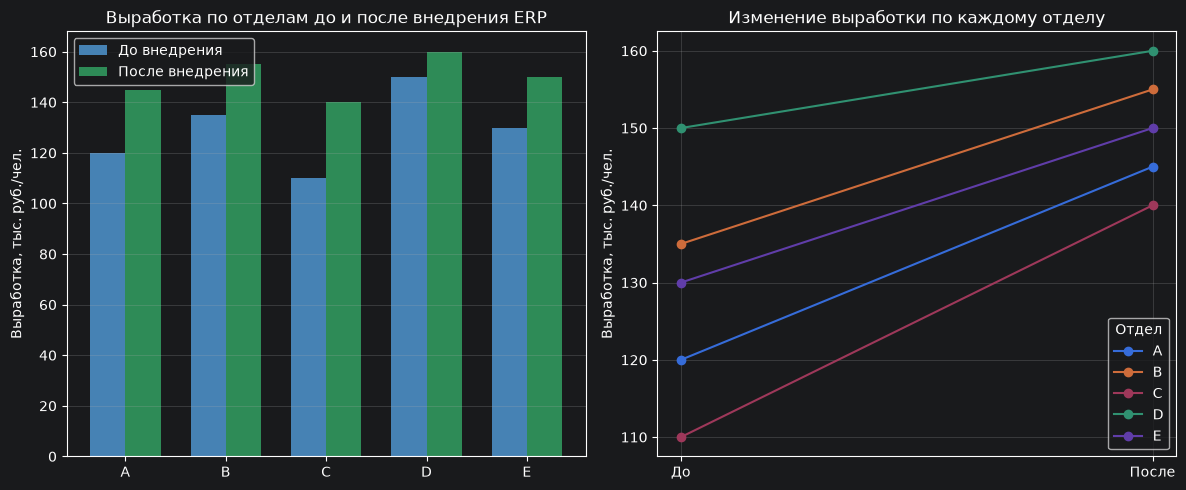

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- Исходные данные ---
departments = ['A', 'B', 'C', 'D', 'E']
before = np.array([120, 135, 110, 150, 130])
after  = np.array([145, 155, 140, 160, 150])

df = pd.DataFrame({
    'Отдел': departments,
    'До внедрения': before,
    'После внедрения': after,
    'Разница': after - before
})
print("=== Данные по отделам ===")
print(df.to_string(index=False))

# --- Описательная статистика ---
mean_before = before.mean()
mean_after = after.mean()
diff = after - before
mean_diff = diff.mean()
std_diff = diff.std(ddof=1)

print(f"\nСредняя выработка до: {mean_before:.2f} тыс. руб./чел.")
print(f"Средняя выработка после: {mean_after:.2f} тыс. руб./чел.")
print(f"Средняя разница: {mean_diff:.2f} тыс. руб./чел.")
print(f"Стд. отклонение разницы: {std_diff:.2f}")

# --- Парный t-тест ---
t_stat, p_value = stats.ttest_rel(after, before)
print(f"\n=== Парный t-тест ===")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

# --- Доверительный интервал для средней разницы (95%) ---
n = len(diff)
se = std_diff / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
ci_low = mean_diff - t_crit * se
ci_high = mean_diff + t_crit * se
print(f"\n95% ДИ для средней разницы: [{ci_low:.2f}; {ci_high:.2f}]")

# --- Размер эффекта (Cohen's d для парных данных) ---
cohen_d = mean_diff / std_diff
print(f"Cohen's d: {cohen_d:.3f}")

# --- Интерпретация ---
alpha = 0.05
print("\n=== Вывод ===")
if p_value < alpha:
    print(f"p-value = {p_value:.6f} < {alpha} → отвергаем H₀.")
    print("Изменение средней выработки статистически значимо.")
else:
    print(f"p-value = {p_value:.6f} ≥ {alpha} → нет оснований отвергать H₀.")
    print("Изменение средней выработки статистически незначимо.")

# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График "до/после" по отделам
x = np.arange(len(departments))
width = 0.35
axes[0].bar(x - width/2, before, width, label='До внедрения', color='steelblue')
axes[0].bar(x + width/2, after, width, label='После внедрения', color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(departments)
axes[0].set_ylabel('Выработка, тыс. руб./чел.')
axes[0].set_title('Выработка по отделам до и после внедрения ERP')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Парный график (спагетти-плот)
for i in range(len(departments)):
    axes[1].plot([0, 1], [before[i], after[i]], marker='o', label=departments[i])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['До', 'После'])
axes[1].set_ylabel('Выработка, тыс. руб./чел.')
axes[1].set_title('Изменение выработки по каждому отделу')
axes[1].legend(title='Отдел')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Ожидаемые результаты

**Данные:**

| Отдел | До | После | Разница |
|---|---|---|---|
| A | 120 | 145 | +25 |
| B | 135 | 155 | +20 |
| C | 110 | 140 | +30 |
| D | 150 | 160 | +10 |
| E | 130 | 150 | +20 |

**Расчёты:**
- Средняя до: 129.0
- Средняя после: 150.0
- Средняя разница: +21.0
- Стд. отклонение разницы: ≈ 7.07
- t-статистика: ≈ 6.64
- p-value: ≈ 0.0027
- 95% ДИ: [12.2; 29.8]
- Cohen's d: ≈ 2.97 (очень большой эффект)


**Вывод:**
p-value ≈ 0.0027 < 0.05 → **отвергаем H₀**. Внедрение ERP-системы привело к **статистически значимому росту** средней выработки на сотрудника. Средний прирост — **21 тыс. руб./чел.**, что составляет около **16.3%** от исходного уровня.
